# 04 - Counting Unique Things With HyperLogLog

How many distinct users visited this month?

It is the most ordinary question in analytics, and the naive answer - put every user id in a `set`
and take its length - stops working at exactly the scale where the question gets interesting. A
hundred million distinct ids is roughly 10 GB of Python `set`. Per query. Per time window. Per
segment you want to slice by.

HyperLogLog answers it in **1,536 bytes**, to within about 2%, in one pass, and two sketches can be
merged without ever comparing the items - so shards, days, or servers can be counted separately
and combined afterwards.

Before the formula, the intuition. It really is about coin flips.

In [1]:
%matplotlib inline

import pandas as pd

from src.config import get_settings
from src.core.hashes import hash_many, leading_zeros
from src.data import generate_stream, generate_unique_items
from src.evaluation.comparison import compare_cardinality
from src.evaluation.error_analysis import count_min_error_report, hyperloglog_error_curve
from src.probabilistic.count_min import CountMinSketch
from src.probabilistic.hyperloglog import HyperLogLog, sizing_for_error, standard_error
from src.results import results_dir, save_results
from src.visualisation import (
    plot_coin_flip_intuition,
    plot_count_min_overshoot,
    plot_hyperloglog_error,
    save_figure,
)

SETTINGS = get_settings()
SEED = SETTINGS.seed
PRECISION = SETTINGS.hyperloglog.precision

print(f"seed = {SEED}, precision p = {PRECISION} "
      f"({1 << PRECISION} registers, {HyperLogLog(PRECISION).packed_memory_bytes():,} bytes packed)")

seed = 20260903, precision p = 11 (2048 registers, 1,536 bytes packed)


## The coin-flip intuition

Someone flips a coin repeatedly and tells you only one thing: the longest run of heads they ever
saw. If they say "three", they probably did not flip many times. If they say "twenty", they almost
certainly flipped about a million times, because a run of twenty heads happens roughly once every
2^20 attempts.

The longest run is *evidence about how many attempts there were* - and remembering it costs one
small number, no matter how many flips happened.

Now hash your items. A good hash gives each one a random-looking bit string, which is a sequence of
coin flips. Count the leading zeros: a hash starting with 20 zeros is that run of twenty heads. And
crucially, **duplicates hash to the same value**, so they contribute nothing new. The longest run
tells you about the number of *distinct* items, which is precisely the question.

In [2]:
rows = []
for n_values in (10, 100, 1_000, 10_000, 100_000, 1_000_000):
    hashes = hash_many([f"item-{i:09d}" for i in range(n_values)], SEED)
    longest = int(leading_zeros(hashes, 64).max())
    rows.append(
        {
            "n_values": n_values,
            "longest_zero_run": longest,
            "naive_estimate_2_to_the_run": 2**longest,
            "ratio_to_truth": 2**longest / n_values,
        }
    )

coin_flips = pd.DataFrame(rows)
coin_flips

,n_values,longest_zero_run,naive_estimate_2_to_the_run,ratio_to_truth
0,10,4,16,1.600000
1,100,7,128,1.280000
2,1000,9,512,0.512000
3,10000,12,4096,0.409600
4,100000,15,32768,0.327680
5,1000000,21,2097152,2.097152


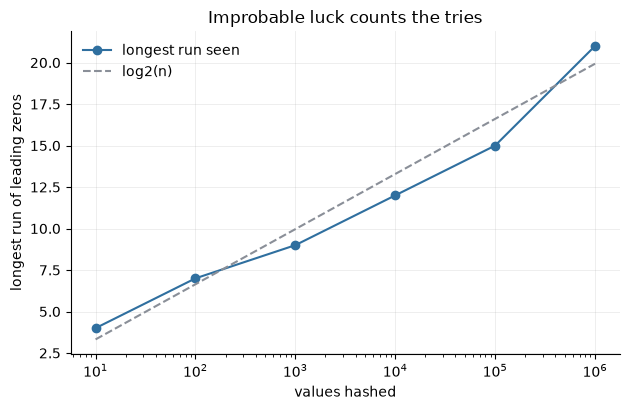

In [3]:
figure = plot_coin_flip_intuition(coin_flips)
save_figure(figure, "04_coin_flip_intuition")
figure

The longest run tracks `log2(n)` closely - the idea works. But look at the `ratio_to_truth`
column: a single run is a wildly noisy estimator, off by a factor of two or four in either
direction, because it depends on one lucky item.

The fix is stochastic averaging, and it is the whole of HyperLogLog. Use the first `p` bits of each
hash to choose one of `m = 2^p` registers, and let each register keep the longest run *it* has
seen. Now you have `m` independent noisy estimates instead of one. Combine them with a harmonic
mean (which suppresses the outliers a plain mean would be dragged around by), multiply by a
bias-correction constant, and the error falls to `1.04 / sqrt(m)`:

```
E = alpha_m * m^2 / sum_j 2^(-M[j])          relative standard error ~ 1.04 / sqrt(m)
```

Each register only needs 6 bits - it stores a small run length, never an item. That is where 1.5 KB
comes from: 2,048 registers times 6 bits.

In [4]:
for target_error in (0.05, 0.02, 0.01):
    chosen = sizing_for_error(target_error)
    print(f"to reach {target_error:.0%} error: p = {chosen.precision:2d}, "
          f"{chosen.n_registers:6,} registers, {chosen.packed_bytes:6,} bytes packed, "
          f"actual error {chosen.standard_error:.2%}")

to reach 5% error: p =  9,    512 registers,    384 bytes packed, actual error 4.60%
to reach 2% error: p = 12,  4,096 registers,  3,072 bytes packed, actual error 1.62%
to reach 1% error: p = 14, 16,384 registers, 12,288 bytes packed, actual error 0.81%


## Counting half a million unique users in 1.5 KB

In [5]:
n_unique = 500_000
users = generate_unique_items(n_unique, seed=SEED)

sketch = HyperLogLog(precision=PRECISION, seed=SEED)
sketch.add_many(users)

estimate = sketch.estimate()
exact_bytes = len(set(users)) * 100  # ~100 bytes per id in a real Python set, measured in nb 03

print(f"true distinct users : {n_unique:,}")
print(f"HyperLogLog says    : {estimate:,.0f}")
print(f"relative error      : {(estimate - n_unique) / n_unique:+.2%} "
      f"(standard error is {sketch.standard_error():.2%})")
print()
print(f"sketch memory       : {sketch.packed_memory_bytes():,} bytes")
print(f"exact set memory    : ~{exact_bytes / 1e6:,.0f} MB")
print(f"ratio               : ~{exact_bytes / sketch.packed_memory_bytes():,.0f}x smaller")

true distinct users : 500,000
HyperLogLog says    : 496,574
relative error      : -0.69% (standard error is 2.30%)

sketch memory       : 1,536 bytes
exact set memory    : ~50 MB
ratio               : ~32,552x smaller


In [6]:
saved = save_results(
    {
        "precision": PRECISION,
        "n_registers": sketch.m,
        "true_cardinality": n_unique,
        "estimate": estimate,
        "relative_error": (estimate - n_unique) / n_unique,
        "standard_error": sketch.standard_error(),
        "packed_memory_bytes": sketch.packed_memory_bytes(),
        "approximate_exact_set_bytes": exact_bytes,
        "zero_registers_remaining": sketch.n_zero_registers(),
    },
    "04_hyperloglog_headline",
)
print("saved ->", saved.name)

saved -> 04_hyperloglog_headline.json


## The accuracy is fixed; the memory is fixed too

This is the property worth internalising. The error does not grow with the count. A sketch of 2,048
registers is about 2.3% wrong when counting a thousand things and about 2.3% wrong when counting a
million - while occupying the same 1,536 bytes either way.

The shaded bands are the theoretical standard error for each precision. Every measured point should
sit inside its band (a couple of sigma), and the bands narrow as `1/sqrt(m)`: four times the memory
halves the error.

In [7]:
error_curve = hyperloglog_error_curve(
    precisions=SETTINGS.hyperloglog.precisions,
    cardinalities=SETTINGS.hyperloglog.cardinalities,
    seed=SEED,
)
error_curve.round(5)

,precision,n_registers,memory_bytes,packed_memory_bytes,true_cardinality,estimate,relative_error,standard_error,within_2_sigma
0,8,256,256,192,1000,1001.12585,0.00113,0.06500,True
1,10,1024,1024,768,1000,1015.09177,0.01509,0.03250,True
2,12,4096,4096,3072,1000,1006.02208,0.00602,0.01625,True
3,14,16384,16384,12288,1000,1004.15241,0.00415,0.00812,True
4,8,256,256,192,10000,9470.32171,-0.05297,0.06500,True
5,10,1024,1024,768,10000,9691.36856,-0.03086,0.03250,True
6,12,4096,4096,3072,10000,9892.38409,-0.01076,0.01625,True
7,14,16384,16384,12288,10000,10050.02750,0.00500,0.00812,True
8,8,256,256,192,100000,118583.64758,0.18584,0.06500,False
9,10,1024,1024,768,100000,106527.24958,0.06527,0.03250,False


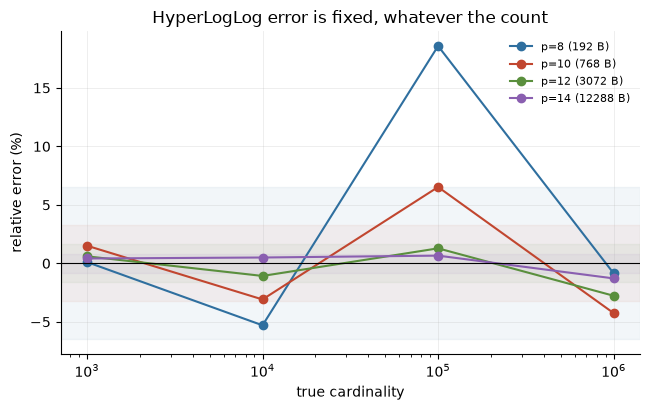

In [8]:
figure = plot_hyperloglog_error(error_curve)
save_figure(figure, "04_hyperloglog_error")
figure

In [9]:
saved = save_results(
    {
        "error_curve": error_curve,
        "within_2_sigma_fraction": float(error_curve["within_2_sigma"].mean()),
        "worst_relative_error": float(error_curve["relative_error"].abs().max()),
        "note": (
            "Memory per precision is constant down each column: the sketch does not grow with "
            "the cardinality it is counting."
        ),
    },
    "04_hyperloglog_error",
)
print("saved ->", saved.name)

saved -> 04_hyperloglog_error.json


## Two properties that make it usable in a real pipeline

**Duplicates are free.** A repeated item hashes to the same register with the same run length and
changes nothing. You can pour a stream through it without deduplicating first - which is the whole
point, since deduplicating is the expensive thing you were trying to avoid.

**Sketches merge.** The union of two sketches is the register-wise maximum: exact, lossless, and
O(m). Count Monday and Tuesday separately, merge for the two-day unique count - something you
simply cannot do with two `COUNT(DISTINCT)` results, and the reason HyperLogLog is in every
distributed analytics engine.

In [10]:
tripled = HyperLogLog(precision=PRECISION, seed=SEED)
tripled.add_many(users * 3)

monday = HyperLogLog(precision=PRECISION, seed=SEED)
monday.add_many(users[: n_unique // 2])
tuesday = HyperLogLog(precision=PRECISION, seed=SEED)
tuesday.add_many(users[n_unique // 3 :])  # deliberately overlapping days
both_days = monday.merge(tuesday)

true_union = len(set(users[: n_unique // 2]) | set(users[n_unique // 3 :]))

print(f"each item seen 3 times -> estimate unchanged: {tripled.estimate() == estimate}")
print()
print(f"monday  : {monday.estimate():>10,.0f}")
print(f"tuesday : {tuesday.estimate():>10,.0f}")
print(f"merged  : {both_days.estimate():>10,.0f}   (true union {true_union:,}, "
      f"error {(both_days.estimate() - true_union) / true_union:+.2%})")
print(f"naive sum would have said {monday.estimate() + tuesday.estimate():,.0f} - "
      "double-counting everyone who came both days")

saved = save_results(
    {
        "duplicates_change_nothing": bool(tripled.estimate() == estimate),
        "monday_estimate": monday.estimate(),
        "tuesday_estimate": tuesday.estimate(),
        "merged_estimate": both_days.estimate(),
        "true_union": true_union,
        "merged_relative_error": (both_days.estimate() - true_union) / true_union,
        "naive_sum": monday.estimate() + tuesday.estimate(),
    },
    "04_merge_and_duplicates",
)
print("saved ->", saved.name)

each item seen 3 times -> estimate unchanged: True

monday  :    251,509
tuesday :    332,286
merged  :    496,574   (true union 500,000, error -0.69%)
naive sum would have said 583,794 - double-counting everyone who came both days
saved -> 04_merge_and_duplicates.json


## Exact versus approximate, measured

In [11]:
cardinality_comparison = compare_cardinality(n_unique=n_unique, precision=PRECISION, seed=SEED)
saved = save_results({"comparison": cardinality_comparison}, "04_exact_vs_approximate")
print("saved ->", saved.name)
cardinality_comparison.round(6)

saved -> 04_exact_vs_approximate.json


,structure,memory_bytes,seconds,estimate,relative_error
0,exact set,44277432,0.086543,500000.000000,0.000000
1,hyperloglog (p=11),1536,0.416205,496574.326026,-0.006851


## The other question: *how often*, not *how many*

HyperLogLog counts distinct items. Count-Min Sketch counts occurrences - "which URLs are being hit
hardest right now", the heavy-hitters question - in a fixed grid of counters.

Same primitive, mirrored error. One counter row per hash; to add an item, increment one cell in
every row; to estimate it, take the **minimum** across rows, because collisions can only ever add
someone else's counts. So the estimate is never *below* the truth, and exceeds it by at most
`epsilon * N` with probability `1 - delta`:

```
w = ceil(e / epsilon) columns,  d = ceil(ln(1/delta)) rows
```

An item the sketch calls rare really is rare - which is exactly what you need when you are looking
for the few things that matter in a stream you cannot store.

In [12]:
stream = generate_stream(
    n_items=SETTINGS.stream.n_items,
    n_unique=SETTINGS.stream.n_unique,
    seed=SEED,
    distribution=SETTINGS.stream.distribution,
    zipf_exponent=SETTINGS.stream.zipf_exponent,
)

sketch_cm = CountMinSketch(
    epsilon=SETTINGS.count_min.epsilon, delta=SETTINGS.count_min.delta, seed=SEED
)
sketch_cm.add_many(stream.items)

exact_counter_bytes = sum(len(key) + 60 for key in stream.true_counts)  # rough, per Python entry

print(sketch_cm)
print(f"stream: {stream.n_items:,} events, {stream.true_cardinality:,} distinct items")
print(f"sketch memory       : {sketch_cm.memory_bytes():,} bytes")
print(f"exact Counter memory: ~{exact_counter_bytes:,} bytes")
print(f"guaranteed overshoot: at most {sketch_cm.error_bound():,.0f} "
      f"({SETTINGS.count_min.epsilon:.1%} of the stream) with probability "
      f"{1 - SETTINGS.count_min.delta:.0%}")

CountMinSketch(epsilon=0.001, delta=0.01, width=2719, depth=5)


stream: 200,000 events, 20,000 distinct items
sketch memory       : 108,760 bytes
exact Counter memory: ~1,460,000 bytes
guaranteed overshoot: at most 200 (0.1% of the stream) with probability 99%


In [13]:
count_min_report = count_min_error_report(
    stream,
    epsilon=SETTINGS.count_min.epsilon,
    delta=SETTINGS.count_min.delta,
    top_k=SETTINGS.count_min.top_k,
    seed=SEED,
)
count_min_report[["item", "true_count", "estimate", "overshoot", "error_bound", "within_bound"]]

,item,true_count,estimate,overshoot,error_bound,within_bound
0,item-00000000,36687,36693,6,200.0,True
1,item-00000001,16064,16074,10,200.0,True
2,item-00000002,9770,9782,12,200.0,True
3,item-00000003,7071,7082,11,200.0,True
4,item-00000004,5352,5356,4,200.0,True
5,item-00000005,4170,4188,18,200.0,True
6,item-00000006,3555,3563,8,200.0,True
7,item-00000007,3035,3052,17,200.0,True
8,item-00000008,2616,2625,9,200.0,True
9,item-00000009,2413,2419,6,200.0,True


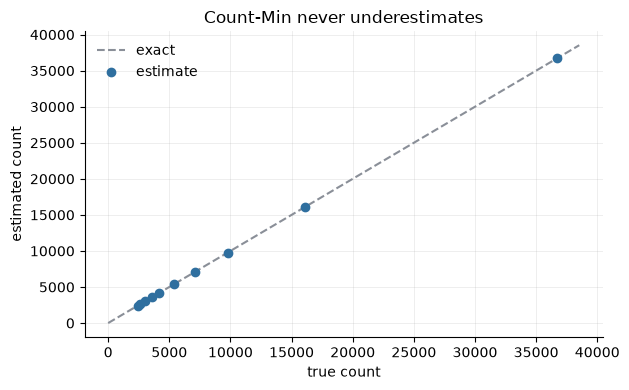

In [14]:
figure = plot_count_min_overshoot(count_min_report)
save_figure(figure, "04_count_min_overshoot")
figure

In [15]:
heavy = sketch_cm.heavy_hitters(stream.true_counts, fraction=0.01)
truly_heavy = [item for item, count in stream.top_k(50) if count >= 0.01 * stream.n_items]

print(f"items the sketch calls heavy (>=1% of the stream): {len(heavy)}")
print(f"items that truly are          : {len(truly_heavy)}")
print(f"the sketch found all of them  : {set(truly_heavy).issubset({item for item, _ in heavy})}")

saved = save_results(
    {
        "stream": {
            "n_items": stream.n_items,
            "n_unique": stream.true_cardinality,
            "distribution": SETTINGS.stream.distribution,
            "zipf_exponent": SETTINGS.stream.zipf_exponent,
        },
        "epsilon": SETTINGS.count_min.epsilon,
        "delta": SETTINGS.count_min.delta,
        "width": sketch_cm.width,
        "depth": sketch_cm.depth,
        "memory_bytes": sketch_cm.memory_bytes(),
        "approximate_exact_counter_bytes": exact_counter_bytes,
        "error_bound": sketch_cm.error_bound(),
        "top_k_report": count_min_report,
        "never_underestimates": bool((count_min_report["overshoot"] >= 0).all()),
        "heavy_hitters_found": len(heavy),
        "heavy_hitters_true": len(truly_heavy),
    },
    "04_count_min",
)
print("saved ->", saved.name)

items the sketch calls heavy (>=1% of the stream): 11
items that truly are          : 11
the sketch found all of them  : True
saved -> 04_count_min.json


## What to take away

- HyperLogLog counts distinct items by watching for improbable luck - the longest run of leading
  zeros in the hashes - and averaging that evidence across `m` registers.
- Error is `1.04 / sqrt(m)` and **does not depend on the cardinality**: ~2.3% at 1,536 bytes,
  whether you are counting a thousand things or a hundred million.
- Duplicates are free, and sketches merge losslessly by taking register-wise maximums, which is why
  every distributed analytics engine has one.
- Count-Min answers the sibling question - how often - with the mirror-image error: it never
  underestimates, and overshoots by at most `epsilon * N`. Heavy hitters stay trustworthy; rare
  items do not.
- Both give up the same thing: the items themselves. You cannot ask either structure *which* users
  it saw. If you need that, you need the memory.

Next: the same trick applied to similarity, where the question is not "have I seen this exact
thing" but "have I seen something almost like it".

In [16]:
takeaways = [
    "HyperLogLog counts uniques from the longest run of leading zeros, averaged over m registers.",
    "Its error is 1.04/sqrt(m) and independent of the true cardinality: ~2.3% in 1,536 bytes.",
    "Duplicates cost nothing and sketches merge losslessly by register-wise maximum.",
    "Count-Min estimates frequencies and never underestimates; it overshoots by at most eps*N.",
    "Both structures discard the items themselves - that is what buys the memory.",
]

saved = save_results({"takeaways": takeaways}, "04_takeaways")
print("saved ->", saved.name)
print("figures:", sorted(path.name for path in SETTINGS.figures.path.glob("04_*.png")))
print("results:", sorted(path.name for path in results_dir().glob("04_*.json")))

saved -> 04_takeaways.json
figures: ['04_coin_flip_intuition.png', '04_count_min_overshoot.png', '04_hyperloglog_error.png']
results: ['04_count_min.json', '04_exact_vs_approximate.json', '04_hyperloglog_error.json', '04_hyperloglog_headline.json', '04_merge_and_duplicates.json', '04_takeaways.json']
